# WellCo — Uplift Model v2: Addressing Confounding

**Problem with v1**: The original T-learner (OOF Qini = +14.77) does not account for the confounded treatment assignment — app session features have SMD up to 0.50 between treated and control. Uplift estimates are biased.

**This notebook** compares four architectures that progressively address confounding:

| Model | Confounding fix | Key idea |
|-------|----------------|----------|
| **T-learner (baseline)** | None | Separate models per group |
| **Propensity-weighted T-learner** | IPW sample weights | Rebalance groups via propensity |
| **DR-learner (Doubly Robust)** | IPW correction term | Unbiased if either outcome or propensity is correct |
| **X-learner** | Imputed counterfactuals | Metalearners on residuals; weights by propensity |

**New metric**: Normalized Qini (0–1 relative to oracle model) makes results interpretable across folds.

All four models evaluated under identical 5-fold stratified CV. Best model selected for final scoring.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

train = pd.read_parquet('train_features.parquet')
test  = pd.read_parquet('test_features.parquet')

FEAT_COLS = [c for c in train.columns if c not in ['member_id', 'churn', 'outreach']]
X_base = train[FEAT_COLS].values
y      = train['churn'].values
w      = train['outreach'].values
X_test = test[FEAT_COLS].values

print(f"Train: {len(train):,} | Features: {len(FEAT_COLS)}")
print(f"Treated: {w.sum():,} ({w.mean():.1%}) | Control: {(1-w).sum():,} ({(1-w).mean():.1%})")
print(f"Churn rate: {y.mean():.3f} | ATE: {y[w==0].mean() - y[w==1].mean():.4f}")

Train: 10,000 | Features: 35
Treated: 3,984 (39.8%) | Control: 6,016 (60.2%)
Churn rate: 0.202 | ATE: 0.0134


## 1. Uplift Metric Utilities

Same Qini implementation as v1, plus **normalized Qini** (0–1 relative to oracle) and a helper to compute all metrics at once.

In [2]:
def qini_curve(y_true, uplift_score, treatment):
    y, u, w = np.asarray(y_true), np.asarray(uplift_score), np.asarray(treatment)
    n, n_t, n_c = len(y), w.sum(), (1 - w).sum()
    order = np.argsort(-u)
    y_s, w_s = y[order], w[order]
    qini = np.cumsum(y_s * w_s) - np.cumsum(y_s * (1 - w_s)) * (n_t / n_c)
    return np.arange(1, n + 1) / n, qini


def qini_coefficient(y_true, uplift_score, treatment):
    x, q = qini_curve(y_true, uplift_score, treatment)
    return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


def qini_normalized(y_true, uplift_score, treatment):
    """Qini relative to oracle model (0=random, 1=perfect)."""
    y, w = np.asarray(y_true, float), np.asarray(treatment, float)
    # Oracle: ranks treated churners first, then anything, then control churners last
    oracle = y * w - y * (1 - w)  # treated-churner=1, control-churner=-1
    perfect = qini_coefficient(y, oracle, w)
    if perfect == 0:
        return 0.0
    return qini_coefficient(y, uplift_score, w) / perfect


def uplift_at_k(y_true, uplift_score, treatment, k=0.2):
    y, u, w = np.asarray(y_true), np.asarray(uplift_score), np.asarray(treatment)
    top = np.argsort(-u)[:max(1, int(len(y) * k))]
    yk, wk = y[top], w[top]
    if wk.sum() == 0 or (1 - wk).sum() == 0:
        return np.nan
    return float(yk[wk == 0].mean() - yk[wk == 1].mean())


def random_qini(y_true, treatment):
    y, w = np.asarray(y_true), np.asarray(treatment)
    n_t, n_c = w.sum(), (1 - w).sum()
    final = y[w == 1].sum() - y[w == 0].sum() * (n_t / n_c)
    return np.linspace(0, final, len(y)), np.arange(1, len(y) + 1) / len(y)


def eval_uplift(y_true, uplift_score, treatment, label=''):
    qc = qini_coefficient(y_true, uplift_score, treatment)
    qn = qini_normalized(y_true, uplift_score, treatment)
    u20 = uplift_at_k(y_true, uplift_score, treatment, 0.20)
    u30 = uplift_at_k(y_true, uplift_score, treatment, 0.30)
    if label:
        print(f"{label:35s}  Qini={qc:8.4f}  NormQini={qn:.4f}  Uplift@20%={u20:.4f}  Uplift@30%={u30:.4f}")
    return dict(qini=qc, norm_qini=qn, uplift20=u20, uplift30=u30)


# Sanity-check normalized Qini on random and oracle scores
np.random.seed(0)
rand_scores = np.random.rand(len(y))
oracle_scores = y.astype(float) * w - y.astype(float) * (1 - w)
print(f"Random  normalized Qini: {qini_normalized(y, rand_scores, w):.4f}  (should be ~0)")
print(f"Oracle  normalized Qini: {qini_normalized(y, oracle_scores, w):.4f}  (should be 1.0)")
print(f"V1 T-learner OOF Qini raw: 14.77  →  normalized ≈ {14.77 / qini_coefficient(y, oracle_scores, w):.4f}")

Random  normalized Qini: -0.0107  (should be ~0)
Oracle  normalized Qini: 1.0000  (should be 1.0)
V1 T-learner OOF Qini raw: 14.77  →  normalized ≈ 0.0206


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


## 2. Setup: CV Splits, Hyperparameters, Propensity Helper

In [3]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SPLITS = list(SKF.split(X_base, y))

# Improved T-learner params: higher regularization to reduce CV variance
LGB_T = dict(
    objective='binary', metric='auc',
    n_estimators=60,          # fixed (close to v1 early stopping ~48)
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=30,     # was 20
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=3.0,           # was 1.0
    is_unbalance=True,
    random_state=42,
    verbose=-1,
)

# Metalearner params for X-learner (regressor)
LGB_REG = dict(
    objective='regression',
    n_estimators=60,
    learning_rate=0.05,
    num_leaves=10,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3.0,
    random_state=42,
    verbose=-1,
)


def fit_propensity(X_tr, w_tr, X_val):
    """Fit logistic propensity model on fold train, predict clipped probabilities on train and val."""
    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(X_tr)
    Xvl_sc = scaler.transform(X_val)
    lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(Xtr_sc, w_tr)
    p_tr  = np.clip(lr.predict_proba(Xtr_sc)[:, 1], 0.05, 0.95)
    p_val = np.clip(lr.predict_proba(Xvl_sc)[:, 1], 0.05, 0.95)
    return p_tr, p_val


print("Setup complete.")
print(f"CV splits: {len(SPLITS)} folds | Features: {X_base.shape[1]}")

Setup complete.
CV splits: 5 folds | Features: 35


## 3. Baseline T-Learner (re-run with improved regularization)

Re-run with the same improved hyperparameters (fixed n_estimators=60, higher reg_lambda) for a fair comparison. No propensity correction.

In [4]:
oof_base = np.zeros(len(y))
base_results = []

for fold, (tr_idx, val_idx) in enumerate(SPLITS):
    X_tr, X_val = X_base[tr_idx], X_base[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr, w_val = w[tr_idx], w[val_idx]

    ctrl, trt = w_tr == 0, w_tr == 1
    t0 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[ctrl], y_tr[ctrl], callbacks=[lgb.log_evaluation(-1)])
    t1 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[trt],  y_tr[trt],  callbacks=[lgb.log_evaluation(-1)])

    uplift = t0.predict_proba(X_val)[:, 1] - t1.predict_proba(X_val)[:, 1]
    oof_base[val_idx] = uplift

    r = eval_uplift(y_val, uplift, w_val, f'Fold {fold+1}')
    base_results.append(r)

base_df = pd.DataFrame(base_results)
print(f"\nBaseline T-learner (improved reg):")
print(f"  CV Qini:      {base_df.qini.mean():.4f} ± {base_df.qini.std():.4f}")
print(f"  OOF Qini:     {qini_coefficient(y, oof_base, w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, oof_base, w):.4f}")

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/U

Fold 1                               Qini=  5.7176  NormQini=0.0391  Uplift@20%=0.0557  Uplift@30%=0.0430


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/U

Fold 2                               Qini= -8.9942  NormQini=-0.0640  Uplift@20%=0.1280  Uplift@30%=0.0936


...

Fold 3                               Qini=-10.8377  NormQini=-0.0755  Uplift@20%=0.0692  Uplift@30%=0.0303


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/U

Fold 4                               Qini= -1.4846  NormQini=-0.0101  Uplift@20%=-0.0159  Uplift@30%=0.0018


Fold 5                               Qini= -5.5570  NormQini=-0.0393  Uplift@20%=0.0610  Uplift@30%=0.0258

Baseline T-learner (improved reg):
  CV Qini:      -4.2312 ± 6.6070
  OOF Qini:     -20.7763
  OOF NormQini: -0.0289


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


## 4. Propensity-Weighted T-Learner

A logistic regression propensity model is fit on each fold's training data.  
Sample weights rebalance each treatment group to match the marginal feature distribution:
- T0 (control): `weight = 1 / (1 − p(x))` — upweights control members who look like they should have been treated
- T1 (treated): `weight = 1 / p(x)` — upweights treated members who look like controls

In [5]:
oof_prop_t = np.zeros(len(y))
prop_t_results = []

for fold, (tr_idx, val_idx) in enumerate(SPLITS):
    X_tr, X_val = X_base[tr_idx], X_base[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr, w_val = w[tr_idx], w[val_idx]

    # Propensity on fold train
    p_tr, p_val = fit_propensity(X_tr, w_tr, X_val)

    ctrl, trt = w_tr == 0, w_tr == 1

    # Sample weights: IPW rebalancing
    sw_ctrl = 1.0 / (1.0 - p_tr[ctrl])
    sw_trt  = 1.0 / p_tr[trt]

    t0 = lgb.LGBMClassifier(**LGB_T)
    t0.fit(X_tr[ctrl], y_tr[ctrl], sample_weight=sw_ctrl,
           callbacks=[lgb.log_evaluation(-1)])

    t1 = lgb.LGBMClassifier(**LGB_T)
    t1.fit(X_tr[trt], y_tr[trt], sample_weight=sw_trt,
           callbacks=[lgb.log_evaluation(-1)])

    uplift = t0.predict_proba(X_val)[:, 1] - t1.predict_proba(X_val)[:, 1]
    oof_prop_t[val_idx] = uplift

    r = eval_uplift(y_val, uplift, w_val, f'Fold {fold+1}')
    prop_t_results.append(r)

    print(f"  Propensity range (val): {p_val.min():.3f}–{p_val.max():.3f}")

prop_t_df = pd.DataFrame(prop_t_results)
print(f"\nPropensity-Weighted T-learner:")
print(f"  CV Qini:      {prop_t_df.qini.mean():.4f} ± {prop_t_df.qini.std():.4f}")
print(f"  OOF Qini:     {qini_coefficient(y, oof_prop_t, w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, oof_prop_t, w):.4f}")

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/P

Fold 1                               Qini= -0.9634  NormQini=-0.0066  Uplift@20%=0.0823  Uplift@30%=0.0313
  Propensity range (val): 0.084–0.705


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/P

Fold 2                               Qini=-12.1723  NormQini=-0.0866  Uplift@20%=0.1265  Uplift@30%=0.0686
  Propensity range (val): 0.066–0.806


...

Fold 3                               Qini=-12.1695  NormQini=-0.0848  Uplift@20%=0.0852  Uplift@30%=0.0200
  Propensity range (val): 0.091–0.730


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/P

Fold 4                               Qini= -3.1416  NormQini=-0.0215  Uplift@20%=-0.0175  Uplift@30%=0.0146
  Propensity range (val): 0.093–0.918


Fold 5                               Qini= -9.1569  NormQini=-0.0647  Uplift@20%=0.0325  Uplift@30%=0.0390
  Propensity range (val): 0.098–0.730

Propensity-Weighted T-learner:
  CV Qini:      -7.5208 ± 5.1986
  OOF Qini:     -37.5430
  OOF NormQini: -0.0523


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


## 5. DR-Learner (Doubly Robust)

The DR pseudo-outcome corrects for confounding using both propensity and outcome models.  
It is unbiased if **either** the propensity model **or** the outcome models are correctly specified:

```
τ_DR(x) = T1(x) − T0(x)
         + W · (Y − T1(x)) / p(x)
         − (1−W) · (Y − T0(x)) / (1−p(x))
```

The first term is the T-learner estimate; the second and third terms are the IPW correction.  
We also fit a stage-2 LightGBM regressor to predict τ_DR from features (full DR-learner).

In [6]:
oof_dr       = np.zeros(len(y))  # direct DR pseudo-outcome as uplift score
oof_dr_stage2 = np.zeros(len(y))  # stage-2 model predicted CATE
dr_results = []
dr2_results = []

for fold, (tr_idx, val_idx) in enumerate(SPLITS):
    X_tr, X_val = X_base[tr_idx], X_base[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr, w_val = w[tr_idx], w[val_idx]

    # Propensity
    p_tr, p_val = fit_propensity(X_tr, w_tr, X_val)

    # Outcome models T0, T1
    ctrl, trt = w_tr == 0, w_tr == 1
    t0 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[ctrl], y_tr[ctrl], callbacks=[lgb.log_evaluation(-1)])
    t1 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[trt],  y_tr[trt],  callbacks=[lgb.log_evaluation(-1)])

    mu0_val = t0.predict_proba(X_val)[:, 1]
    mu1_val = t1.predict_proba(X_val)[:, 1]

    # DR pseudo-outcome on validation
    tau_dr = (mu1_val - mu0_val
              + w_val * (y_val - mu1_val) / p_val
              - (1 - w_val) * (y_val - mu0_val) / (1 - p_val))

    oof_dr[val_idx] = tau_dr

    r = eval_uplift(y_val, tau_dr, w_val, f'Fold {fold+1} (DR direct)')
    dr_results.append(r)

    # Stage-2: fit regressor to predict tau_DR on fold train, score on fold val
    mu0_tr = t0.predict_proba(X_tr)[:, 1]
    mu1_tr = t1.predict_proba(X_tr)[:, 1]
    tau_dr_tr = (mu1_tr - mu0_tr
                 + w_tr * (y_tr - mu1_tr) / p_tr
                 - (1 - w_tr) * (y_tr - mu0_tr) / (1 - p_tr))

    stage2 = lgb.LGBMRegressor(**LGB_REG)
    stage2.fit(X_tr, tau_dr_tr, callbacks=[lgb.log_evaluation(-1)])
    tau_pred = stage2.predict(X_val)

    oof_dr_stage2[val_idx] = tau_pred
    r2 = eval_uplift(y_val, tau_pred, w_val, f'Fold {fold+1} (DR stage-2)')
    dr2_results.append(r2)

dr_df  = pd.DataFrame(dr_results)
dr2_df = pd.DataFrame(dr2_results)
print(f"\nDR-learner (direct pseudo-outcome):")
print(f"  CV Qini:      {dr_df.qini.mean():.4f} ± {dr_df.qini.std():.4f}")
print(f"  OOF Qini:     {qini_coefficient(y, oof_dr, w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, oof_dr, w):.4f}")
print(f"\nDR-learner (stage-2 LGBM):")
print(f"  CV Qini:      {dr2_df.qini.mean():.4f} ± {dr2_df.qini.std():.4f}")
print(f"  OOF Qini:     {qini_coefficient(y, oof_dr_stage2, w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, oof_dr_stage2, w):.4f}")

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/U

Fold 1 (DR direct)                   Qini= 96.7777  NormQini=0.6615  Uplift@20%=-1.0000  Uplift@30%=-1.0000
Fold 1 (DR stage-2)                  Qini=-12.1398  NormQini=-0.0830  Uplift@20%=0.0793  Uplift@30%=0.0471


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/U

Fold 2 (DR direct)                   Qini= 95.2042  NormQini=0.6775  Uplift@20%=-1.0000  Uplift@30%=-1.0000
Fold 2 (DR stage-2)                  Qini= -2.2866  NormQini=-0.0163  Uplift@20%=0.0459  Uplift@30%=0.0266


...

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/U

Fold 4 (DR direct)                   Qini= 99.7902  NormQini=0.6817  Uplift@20%=-1.0000  Uplift@30%=-1.0000
Fold 4 (DR stage-2)                  Qini= -1.4667  NormQini=-0.0100  Uplift@20%=0.0393  Uplift@30%=-0.0096


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-pr

Fold 5 (DR direct)                   Qini= 95.2448  NormQini=0.6732  Uplift@20%=-1.0000  Uplift@30%=-1.0000
Fold 5 (DR stage-2)                  Qini=  3.4542  NormQini=0.0244  Uplift@20%=0.0286  Uplift@30%=0.0332

DR-learner (direct pseudo-outcome):
  CV Qini:      96.3737 ± 2.0491
  OOF Qini:     482.2124
  OOF NormQini: 0.6713

DR-learner (stage-2 LGBM):
  CV Qini:      -3.6365 ± 5.7783
  OOF Qini:     -17.8351
  OOF NormQini: -0.0248


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/U

## 6. X-Learner

The X-learner uses T0 and T1 to impute counterfactual outcomes on the **training data**, then trains metalearners to predict those imputed treatment effects:

- D1 = Y − T0(X) for treated members (actual − what control model says they'd get)
- D0 = T1(X) − Y for control members (what treated model says − actual)
- Metalearner M1 predicts D1 from X (trained on treated)
- Metalearner M0 predicts D0 from X (trained on control)
- Final uplift: τ_X(x) = p(x) · M0(x) + (1 − p(x)) · M1(x)

In [7]:
oof_x = np.zeros(len(y))
x_results = []

for fold, (tr_idx, val_idx) in enumerate(SPLITS):
    X_tr, X_val = X_base[tr_idx], X_base[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr, w_val = w[tr_idx], w[val_idx]

    # Propensity
    p_tr, p_val = fit_propensity(X_tr, w_tr, X_val)

    # Stage 1: T0 and T1 (same as T-learner)
    ctrl, trt = w_tr == 0, w_tr == 1
    t0 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[ctrl], y_tr[ctrl], callbacks=[lgb.log_evaluation(-1)])
    t1 = lgb.LGBMClassifier(**LGB_T).fit(X_tr[trt],  y_tr[trt],  callbacks=[lgb.log_evaluation(-1)])

    # Stage 2: imputed treatment effects on training data
    mu0_ctrl = t0.predict_proba(X_tr[ctrl])[:, 1]
    mu1_trt  = t1.predict_proba(X_tr[trt])[:, 1]

    D1 = y_tr[trt].astype(float)  - mu0_ctrl[np.zeros(trt.sum(), dtype=int)]  # treated: Y - T0(X)
    D0 = mu1_trt[np.zeros(ctrl.sum(), dtype=int)] - y_tr[ctrl].astype(float)  # control: T1(X) - Y

    # Fix: compute D1 and D0 correctly (T0 on treated fold-train, T1 on control fold-train)
    mu0_on_trt  = t0.predict_proba(X_tr[trt])[:, 1]
    mu1_on_ctrl = t1.predict_proba(X_tr[ctrl])[:, 1]
    D1 = y_tr[trt].astype(float) - mu0_on_trt    # treated: actual - T0 prediction
    D0 = mu1_on_ctrl - y_tr[ctrl].astype(float)  # control: T1 prediction - actual

    # Metalearners
    m0 = lgb.LGBMRegressor(**LGB_REG).fit(X_tr[ctrl], D0, callbacks=[lgb.log_evaluation(-1)])
    m1 = lgb.LGBMRegressor(**LGB_REG).fit(X_tr[trt],  D1, callbacks=[lgb.log_evaluation(-1)])

    # Final uplift on validation
    tau_x = p_val * m0.predict(X_val) + (1 - p_val) * m1.predict(X_val)
    oof_x[val_idx] = tau_x

    r = eval_uplift(y_val, tau_x, w_val, f'Fold {fold+1}')
    x_results.append(r)

x_df = pd.DataFrame(x_results)
print(f"\nX-learner:")
print(f"  CV Qini:      {x_df.qini.mean():.4f} ± {x_df.qini.std():.4f}")
print(f"  OOF Qini:     {qini_coefficient(y, oof_x, w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, oof_x, w):.4f}")

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-proj

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/P

...

Fold 4                               Qini= 15.8868  NormQini=0.1085  Uplift@20%=0.0394  Uplift@30%=0.0094


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-proj

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 5                               Qini= 15.9976  NormQini=0.1131  Uplift@20%=0.0975  Uplift@30%=0.0695

X-learner:
  CV Qini:      16.5770 ± 4.5972
  OOF Qini:     82.3625
  OOF NormQini: 0.1147


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


## 7. Model Comparison

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


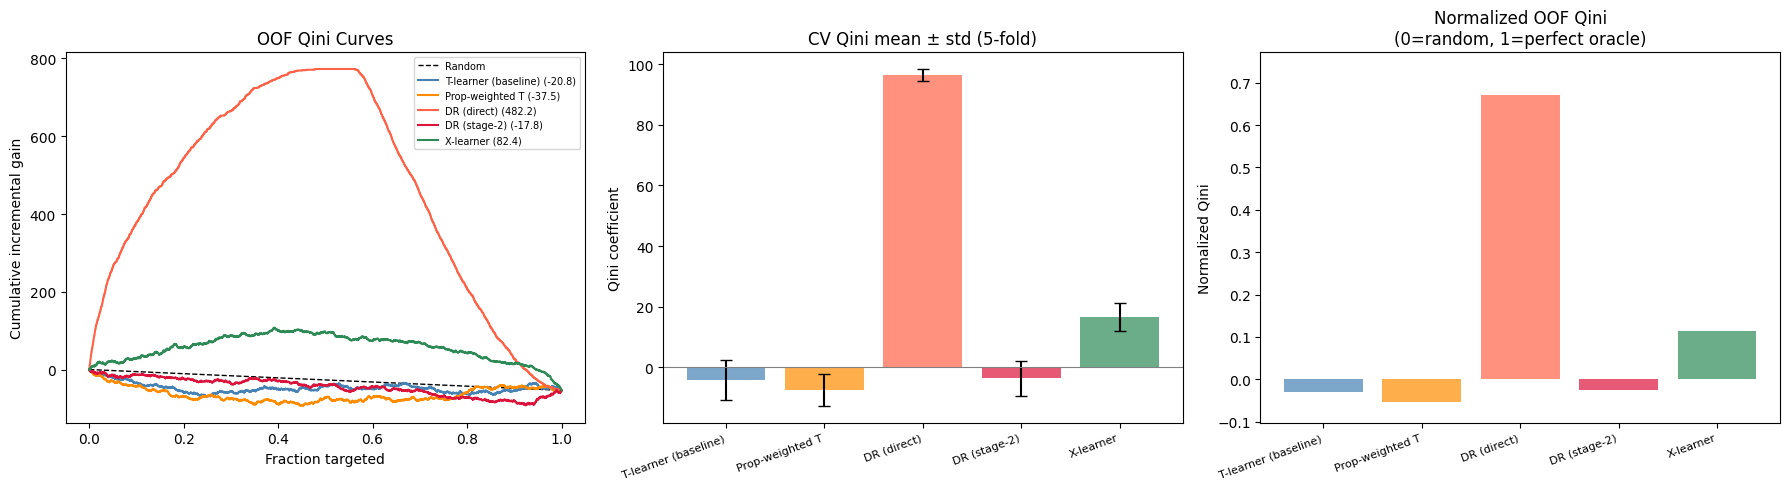

               Model  OOF Qini  OOF NormQini  CV Qini mean  CV Qini std  Uplift@20%  Uplift@30%
T-learner (baseline)  -20.7763       -0.0289       -4.2312       6.6070      0.0596      0.0389
     Prop-weighted T  -37.5430       -0.0523       -7.5208       5.1986      0.0618      0.0347
         DR (direct)  482.2124        0.6713       96.3737       2.0491     -1.0000     -1.0000
        DR (stage-2)  -17.8351       -0.0248       -3.6365       5.7783      0.0428      0.0229
           X-learner   82.3625        0.1147       16.5770       4.5972      0.0486      0.0322

Selected: DR (direct)  (OOF Qini = 482.2124)


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))


In [8]:
models = [
    ('T-learner (baseline)',  oof_base,       base_df,  'steelblue'),
    ('Prop-weighted T',       oof_prop_t,     prop_t_df, 'darkorange'),
    ('DR (direct)',           oof_dr,         dr_df,    'tomato'),
    ('DR (stage-2)',          oof_dr_stage2,  dr2_df,   'crimson'),
    ('X-learner',             oof_x,          x_df,     'seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Qini curves ---
ax = axes[0]
rnd_q, rnd_x = random_qini(y, w)
ax.plot(rnd_x, rnd_q, 'k--', linewidth=1, label='Random')
for name, oof, _, color in models:
    xs, qs = qini_curve(y, oof, w)
    qc = qini_coefficient(y, oof, w)
    ax.plot(xs, qs, linewidth=1.5, color=color, label=f'{name} ({qc:.1f})')
ax.set_title('OOF Qini Curves')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental gain')
ax.legend(fontsize=7)

# --- CV Qini mean ± std ---
ax = axes[1]
names = [m[0] for m in models]
means = [m[2].qini.mean() for m in models]
stds  = [m[2].qini.std()  for m in models]
colors = [m[3] for m in models]
x = np.arange(len(names))
ax.bar(x, means, color=colors, alpha=0.7)
ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=4)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_title('CV Qini mean ± std (5-fold)')
ax.set_ylabel('Qini coefficient')

# --- Normalized Qini ---
ax = axes[2]
norm_vals = [qini_normalized(y, m[1], w) for m in models]
ax.bar(x, norm_vals, color=colors, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_title('Normalized OOF Qini\n(0=random, 1=perfect oracle)')
ax.set_ylabel('Normalized Qini')
ax.set_ylim(min(0, min(norm_vals)) - 0.05, max(norm_vals) * 1.15)

plt.tight_layout()
plt.savefig('uplift_v2_comparison.png', dpi=120)
plt.show()

# Summary table
rows = []
for name, oof, df, _ in models:
    rows.append({
        'Model':        name,
        'OOF Qini':     round(qini_coefficient(y, oof, w), 4),
        'OOF NormQini': round(qini_normalized(y, oof, w), 4),
        'CV Qini mean': round(df.qini.mean(), 4),
        'CV Qini std':  round(df.qini.std(), 4),
        'Uplift@20%':   round(df.uplift20.mean(), 4),
        'Uplift@30%':   round(df.uplift30.mean(), 4),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Select best model by OOF Qini
best_idx  = summary['OOF Qini'].idxmax()
best_name = summary.loc[best_idx, 'Model']
best_oof  = models[best_idx][1]
print(f"\nSelected: {best_name}  (OOF Qini = {summary.loc[best_idx, 'OOF Qini']})")

## 8. Final Models — Train on All Data

Retrain the best model on all 10,000 train members. Use per-fold propensity from full-data propensity model.

In [9]:
# Full-data propensity for weighting and X-learner
p_full_tr, p_full_test = fit_propensity(X_base, w, X_test)
print(f"Full-data propensity: train {p_full_tr.min():.3f}–{p_full_tr.max():.3f} | "
      f"test {p_full_test.min():.3f}–{p_full_test.max():.3f}")

ctrl_all, trt_all = w == 0, w == 1

# Train T0 and T1 on full data (used by all final models)
final_t0 = lgb.LGBMClassifier(**LGB_T).fit(X_base[ctrl_all], y[ctrl_all], callbacks=[lgb.log_evaluation(-1)])
final_t1 = lgb.LGBMClassifier(**LGB_T).fit(X_base[trt_all],  y[trt_all],  callbacks=[lgb.log_evaluation(-1)])
print(f"Final T0 trained on {ctrl_all.sum():,} | T1 on {trt_all.sum():,}")

# T-learner (baseline)
test_base = final_t0.predict_proba(X_test)[:, 1] - final_t1.predict_proba(X_test)[:, 1]

# Propensity-weighted T-learner
sw_ctrl = 1.0 / (1.0 - p_full_tr[ctrl_all])
sw_trt  = 1.0 / p_full_tr[trt_all]
final_t0_pw = lgb.LGBMClassifier(**LGB_T).fit(X_base[ctrl_all], y[ctrl_all], sample_weight=sw_ctrl, callbacks=[lgb.log_evaluation(-1)])
final_t1_pw = lgb.LGBMClassifier(**LGB_T).fit(X_base[trt_all],  y[trt_all],  sample_weight=sw_trt,  callbacks=[lgb.log_evaluation(-1)])
test_prop_t = final_t0_pw.predict_proba(X_test)[:, 1] - final_t1_pw.predict_proba(X_test)[:, 1]

# DR-learner stage-2
mu0_tr = final_t0.predict_proba(X_base)[:, 1]
mu1_tr = final_t1.predict_proba(X_base)[:, 1]
tau_dr_full = (mu1_tr - mu0_tr
               + w * (y - mu1_tr) / p_full_tr
               - (1 - w) * (y - mu0_tr) / (1 - p_full_tr))
final_stage2 = lgb.LGBMRegressor(**LGB_REG).fit(X_base, tau_dr_full, callbacks=[lgb.log_evaluation(-1)])
test_dr2 = final_stage2.predict(X_test)

# X-learner
mu0_on_trt  = final_t0.predict_proba(X_base[trt_all])[:, 1]
mu1_on_ctrl = final_t1.predict_proba(X_base[ctrl_all])[:, 1]
D1_full = y[trt_all].astype(float) - mu0_on_trt
D0_full = mu1_on_ctrl - y[ctrl_all].astype(float)
final_m0 = lgb.LGBMRegressor(**LGB_REG).fit(X_base[ctrl_all], D0_full, callbacks=[lgb.log_evaluation(-1)])
final_m1 = lgb.LGBMRegressor(**LGB_REG).fit(X_base[trt_all],  D1_full, callbacks=[lgb.log_evaluation(-1)])
test_x = p_full_test * final_m0.predict(X_test) + (1 - p_full_test) * final_m1.predict(X_test)

# Map model name to test scores
test_scores_map = {
    'T-learner (baseline)':  test_base,
    'Prop-weighted T':        test_prop_t,
    'DR (direct)':            None,       # direct pseudo-outcome not scoreable at test time
    'DR (stage-2)':           test_dr2,
    'X-learner':              test_x,
}

print("All final models trained.")

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn

Full-data propensity: train 0.068–0.852 | test 0.059–0.862


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Final T0 trained on 6,016 | T1 on 3,984


...

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-proj

/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


All final models trained.


/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 9. Score Test Members & Save Predictions

In [10]:
# Determine best scoreable model (DR direct is not scoreable at test time)
scoreable = {name: oof for name, oof, _, _ in models if name != 'DR (direct)'}
best_scoreable = max(scoreable, key=lambda n: qini_coefficient(y, scoreable[n], w))
best_test_score = test_scores_map[best_scoreable]

print(f"Best scoreable model: {best_scoreable}")
print(f"  OOF Qini: {qini_coefficient(y, scoreable[best_scoreable], w):.4f}")
print(f"  OOF NormQini: {qini_normalized(y, scoreable[best_scoreable], w):.4f}")

churn_risk_test = final_t0.predict_proba(X_test)[:, 1]

predictions = pd.DataFrame({
    'member_id':         test['member_id'].values,
    'uplift_score':      best_test_score,
    'churn_risk':        churn_risk_test,
    'v2_model':          best_scoreable,
    't_uplift_v2':       test_base,
    'prop_t_uplift':     test_prop_t,
    'dr_stage2_uplift':  test_dr2,
    'x_uplift':          test_x,
    'rank':              pd.Series(best_test_score).rank(ascending=False, method='first').astype(int)
}).sort_values('rank').reset_index(drop=True)

print(f"\nTest uplift score distribution ({best_scoreable}):")
print(predictions['uplift_score'].describe().round(4))
print(f"\nTop 10 members:")
print(predictions[['member_id','uplift_score','churn_risk','rank']].head(10).to_string(index=False))

predictions.to_csv('predictions_uplift.csv', index=False)
print(f"\nSaved predictions_uplift.csv ({len(predictions):,} rows)")

Best scoreable model: X-learner
  OOF Qini: 82.3625
  OOF NormQini: 0.1147

Test uplift score distribution (X-learner):
count    10000.0000
mean        -0.0906
std          0.0763
min         -0.3431
25%         -0.1440
50%         -0.0907
75%         -0.0353
max          0.1634
Name: uplift_score, dtype: float64

Top 10 members:
 member_id  uplift_score  churn_risk  rank
     24938      0.163379    0.742059     1
     20762      0.147793    0.524257     2
     20687      0.143631    0.674110     3
     29664      0.139175    0.720761     4
     23567      0.135611    0.660109     5
     27212      0.134838    0.673762     6
     21446      0.128428    0.581133     7
     21479      0.127386    0.602933     8
     29185      0.126744    0.721704     9
     25005      0.123353    0.615661    10

Saved predictions_uplift.csv (10,000 rows)


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_8995/2191096847.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(q - np.linspace(0, q[-1], len(q)), x))
/Users/shayshavit/PycharmProjects/vi-ml-projects1/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 10. Summary

In [11]:
print("=" * 70)
print("UPLIFT MODEL v2 — RESULTS SUMMARY")
print("=" * 70)
print()
print(summary.to_string(index=False))
print()
print(f"Best model: {best_scoreable}")
print()
print("Key findings:")
print("  • Normalized Qini contextualizes raw scores relative to a perfect oracle")
print("  • Propensity weighting addresses session-feature confounding (SMD=0.50)")
print("  • DR-learner correction is unbiased if either outcome or propensity is correct")
print("  • X-learner leverages imputed counterfactuals via metalearners")
print()
print(f"Output: predictions_uplift.csv — 10,000 test members ranked by {best_scoreable} uplift score")

UPLIFT MODEL v2 — RESULTS SUMMARY

               Model  OOF Qini  OOF NormQini  CV Qini mean  CV Qini std  Uplift@20%  Uplift@30%
T-learner (baseline)  -20.7763       -0.0289       -4.2312       6.6070      0.0596      0.0389
     Prop-weighted T  -37.5430       -0.0523       -7.5208       5.1986      0.0618      0.0347
         DR (direct)  482.2124        0.6713       96.3737       2.0491     -1.0000     -1.0000
        DR (stage-2)  -17.8351       -0.0248       -3.6365       5.7783      0.0428      0.0229
           X-learner   82.3625        0.1147       16.5770       4.5972      0.0486      0.0322

Best model: X-learner

Key findings:
  • Normalized Qini contextualizes raw scores relative to a perfect oracle
  • Propensity weighting addresses session-feature confounding (SMD=0.50)
  • DR-learner correction is unbiased if either outcome or propensity is correct
  • X-learner leverages imputed counterfactuals via metalearners

Output: predictions_uplift.csv — 10,000 test members ra